# Profiles of T/s anomalies

### input files

In [1]:


#time domain
yrst = 2006 ; yren  = 2026
clst = yrst ; clen = 2018



# # # EN4
# src  = 'EN4'
# expt = 'obs'
# diri = '/g/data/gv90/wrh581/'
# prefix = src+'/EN.4.2.2.?.analysis.l09.'
# sNam = 'salinity' ; tNam = 'temperature'   #variable names


# ORAS5
src  = 'ORAS5'
expt = 'rean'
diri = '/g/data/gv90/wrh581/ORAS5/'  #'/g/data/lo70/hs5546/ORAS5/*/'
sNam = 'vosaline' ; tNam = 'votemper'   #variable names

# # IAP
# src  = 'IAP'
# expt = 'obs'
# diri = '/g/data/gv90/wrh581/'+src+'/'  #'/g/data/lo70/hs5546/ORAS5/*/'
# sNam = 'salinity' ; tNam = 'temp'   #variable names



#output directory
diro = 'gd/Obs-seaice-analysis/plots/'


### time/space sector definitions

In [2]:


#depth
zmin = 0. ; zmax = 400.


#sectors
sector = {
        'Circumpolar' : {'minlon' : 0.,  'maxlon' : 360., 'minlat' : -70., 'maxlat' : -55},
        'E. hemisphere' : {'minlon' : 330., 'maxlon' : 90.,  'minlat' : -65., 'maxlat' : -55.},
        'E. Antarctic' : {'minlon' : 30., 'maxlon' : 90.,  'minlat' : -65., 'maxlat' : -60.},
        'Bellingshausen' : {'minlon' : 277.,  'maxlon' : 297., 'minlat' : -72., 'maxlat' : -60},
        'Weddell' : {'minlon' : 330., 'maxlon' : 30.,  'minlat' : -65., 'maxlat' : -55.},
        'Ross' : {'minlon' : 160., 'maxlon' : 230.,  'minlat' : -75., 'maxlat' : -59.}
}



In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import matplotlib as mpl
import numpy as np
import xarray as xr
import cf_xarray as cf
import pandas as pd
import gsw              #TEOS-10 package
import cmocean as cm

import logging
logging.getLogger("flox").setLevel(logging.WARNING) #tell flox to get floxed!

import sys
sys.path.append('/g/data/jk72/wrh581/Southern-Ocean-ice-potential')
import zcrit_Hcrit_calc as zcalc
import read_functions as rd
import dask_optimise as daskopt


#method of calculating Freeze condition aka SaFT 
SaFT_method = zcalc.freeze_condition_continuous

#spin up dask
from dask.distributed import Client, LocalCluster

config = daskopt.get_dask_config()
cluster = LocalCluster(**config)
Client = Client(cluster)
Client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 28,Total memory: 94.50 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33957,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34047,Total threads: 2
Dashboard: /proxy/34165/status,Memory: 6.75 GiB
Nanny: tcp://127.0.0.1:35497,


2026-07-16 16:03:02,439 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:38277 (pid=4061710) exceeded 90% memory budget. Restarting...
2026-07-16 16:03:02,544 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:38277' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('getitem-45e669a48caacbb40cb06f1ecc283ca6', 4, 0, 0, 1), 'original-open_dataset-votemper-039893f6854f946fa9ebac582820ca60', ('shuffle-split-82e9fde5bd2c582cc10431becc3033ff', 200), ('getitem-82e9fde5bd2c582cc10431becc3033ff', 18, 0, 0, 6), ('getitem-86ed23c2e1f9bfaf2aedaa827af0f3c5', 2, 0, 0, 0), ('getitem-82e9fde5bd2c582cc10431becc3033ff', 13, 0, 1, 6)} (stimulus_id='handle-worker-cleanup-1784181782.544297')
2026-07-16 16:03:02,609 - distributed.nanny - WARNING - Restarting worker
2026-07-16 16:03:05,524 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:44507 (pid=4061707) exceeded 90% memory budget. Restarting...
2026-07-16 16:03:05,670 - 

### Read T/S data

In [4]:
kwargs = { 'src' : src,
        'expt' : expt,
        'start_year' : yrst,
        'end_year' : yren,
        'zmin' : zmin, 'zmax' : zmax,
        'latmin' : -75., 'latmax' : -50.
       }


if src == 'IAP':
#ridiculous hack, because IAP T amd S data are on different grids
    data = xr.Dataset({tNam : rd.ocean_read(var = tNam, **kwargs)})
    S = rd.ocean_read(var = sNam, **kwargs)
    import xesmf
    regrid_wgts = xesmf.Regridder(S, data[tNam], 'bilinear', periodic= True)
    data = data.assign({sNam : regrid_wgts(S.where(S < 100))})

else:
    data = xr.Dataset({
        tNam : rd.ocean_read(var = tNam, **kwargs),
        sNam : rd.ocean_read(var = sNam, **kwargs)
    })


In [5]:
# correct attributes/units

if (src == 'EN4'):
    #add some attributes    
    data[sNam].attrs['units'] = 'PSU'
    data[tNam].attrs['units'] = 'K'
    data[tNam].attrs['long_name'] = 'Potential temperature'

elif (src == 'ORAS5'):
    #add correct attribute to temperature var
    data[tNam].attrs['long_name'] = 'Potential temperature'

elif (src == 'IAP'):
    data = data.transpose('time','depth_std','lat','lon')
    data[sNam].attrs['long_name'] = 'Absolute Salinity'
    data[sNam].attrs['units'] = 'g/kg'

In [6]:
#add area weights

if (src == 'ACCESS-OM2'):
    import intake
    var = 'area_t'
    catalog = intake.cat.access_nri.search(model = src,variable = var)
    pattern = catalog[expt].search(variable = var).df['path']     #get filepaths from intake catalog

    data = data.assign({
        'wgts' : xr.open_dataset(pattern[0])[var].cf.sel(latitude = slice(kwargs['latmin'], kwargs['latmax'])) 
        })
else:
    data = data.assign({'wgts' : (data.cf['latitude'].dims,  np.cos(np.deg2rad(data.cf['latitude'])).values)})  

In [7]:
#add cell thickness

if (src == 'ACCESS-OM2'):

    #add cell thickness
    try:
        dz =  rd.ocean_read(var = 'dht', **kwargs) 
    except:

        import intake

        var = 'st_edges_ocean'
        catalog = intake.cat.access_nri.search(model = src,variable = var)
        pattern = catalog[expt].search(variable = var).df['path'] 
        dz = xr.open_dataset(pattern[0], decode_timedelta = False)[var]

        dz = (dz[1:] - dz[:-1].values)
        dz = dz.rename({ var : data[tNam].dims[1]})
  
    data = data.assign({'dz' : (data[tNam].dims[1], 
            dz.cf.isel(vertical = slice(0, data[data[tNam].dims[1]].size)).data)})
        
elif (src == 'EN4'):

    #add cell thickness
    dz = data.depth_bnds[0,:,1] - data.depth_bnds[0,:,0].values
    data = data.assign({'dz' : (data[tNam].dims[1], dz.data)})
        


else:
    
    #add cell thickness (inexact but ok for weighting
    zNam = data[tNam].dims[1] 
    dz = data[zNam].copy()
    dz.values[0] = 2.* dz[0].values
    dz.values[1:] = data[zNam][1:].values - data[zNam][:-1].values
    data = data.assign({'dz' : dz})

    #rename time coord
    data = data.rename({ data.cf['time'].name : 'time'})


dNams = data[tNam].dims           #dimension names
zNam = dNams[1] ; yNam = dNams[2] ; xNam = dNams[3] # make the dim names a bit more 'readable' later

data = data.chunk({'time' : 1, zNam : -1, yNam : -1, xNam : -1})

### Get sector means

In [8]:
#reset sector def. longitudes (e.g. MOM coords)

def lonpivot(pivot):
    def MOMlon(lon):
        if pivot == 360.:
           if (lon < 0.) : lon = lon + 360. 
        else:
            if (lon > pivot): lon = lon - 360.
        return(lon)

    for i in sector:
        xrange              = sector[i]['maxlon'] - sector[i]['minlon']
        #circumpolar special case
        if xrange == 360.:
            if pivot == 360.:
                sector[i]['minlon'] = 0.
            else:
                sector[i]['minlon'] = -pivot
            sector[i]['maxlon'] = pivot
        else:
            sector[i]['minlon'] = MOMlon(sector[i]['minlon'])
            sector[i]['maxlon'] = MOMlon(sector[i]['maxlon'])
    

pivot = data.cf['longitude'].min().values.item()
if (pivot < 0.):
    pivot = data.cf['longitude'].max().values.item()

lonpivot(pivot)



In [9]:

sector_mean_list = []
for sname, sdef in sector.items():
    if  sdef['minlon'] < sdef['maxlon']:
        sector_mask = (
            (data.cf['longitude'] >= sdef['minlon']) &
            (data.cf['longitude'] <= sdef['maxlon']) &
            (data.cf['latitude']  >= sdef['minlat']) &
            (data.cf['latitude']  <= sdef['maxlat'])
        )
    else:   #for sectors crossing the pivot point
            sector_mask = (
            ((data.cf['longitude'] >= sdef['minlon']) |
            (data.cf['longitude'] <= sdef['maxlon']) ) &
            (data.cf['latitude']  >= sdef['minlat']) &
            (data.cf['latitude']  <= sdef['maxlat'])
        )

    sm = (
    data.where(sector_mask)
        .weighted(data['wgts'])
        .mean(dim=(yNam, xNam))
        .assign_coords(sector=sname)
        .compute()# ← compute each sector individually
    )       
            
    sector_mean_list.append(sm)


sector_mean = xr.concat(sector_mean_list, dim="sector")

sector_mean = sector_mean.chunk({'time': -1, 'sector' : 1, zNam: -1})
sector_mean

2026-07-16 16:02:04,939 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 5.41 GiB -- Worker memory limit: 6.75 GiB
2026-07-16 16:02:05,518 - distributed.worker.memory - WARNING - Worker is at 42% memory usage. Resuming worker. Process memory: 2.86 GiB -- Worker memory limit: 6.75 GiB
2026-07-16 16:02:20,883 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 5.47 GiB -- Worker memory limit: 6.75 GiB
2026-07-16 16:02:21,199 - distributed.worker.memory - WARNING - Worker is at 62% memory usage. Resuming worker. Process memory: 4.23 GiB -- Worker memory limit: 6.75 GiB
2026-07-16 16:02:37,201 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 5.43 GiB -- Worker memory limit: 6.75 GiB
2026-07-16 16:02:37,800 - distributed.worker.memory - WARNING - Worker is at 62% memory usage. Resuming worker. Process memory: 4.23 GiB -- Worker mem

<xarray.Dataset> Size: 440kB
Dimensions:   (sector: 6, time: 246, deptht: 37)
Coordinates:
  * sector    (sector) <U14 336B 'Circumpolar' 'E. hemisphere' ... 'Ross'
  * time      (time) datetime64[ns] 2kB 2006-01-16 2006-02-15 ... 2026-06-16
  * deptht    (deptht) float32 148B 0.5058 1.556 2.668 ... 300.9 333.9 370.7
Data variables:
    votemper  (sector, time, deptht) float32 218kB dask.array<chunksize=(1, 246, 37), meta=np.ndarray>
    vosaline  (sector, time, deptht) float32 218kB dask.array<chunksize=(1, 246, 37), meta=np.ndarray>
    wgts      (sector) float32 24B dask.array<chunksize=(1,), meta=np.ndarray>
    dz        (sector, deptht) float32 888B dask.array<chunksize=(1, 37), meta=np.ndarray>

### various data transformations/corrections

In [10]:

#calc P
P = gsw.p_from_z(-sector_mean[zNam], -65.)


#convert Practical to Absolute Salinity if required
#convert Practical to Absolute Salinity if required
if np.isin(sector_mean[sNam].units, ['psu','PSU',1]): 
    for region in sector:
        selcond = {'sector' : region}
        sector_mean[sNam].loc[selcond] = gsw.SA_from_SP(sector_mean[sNam].sel(**selcond),P,
                       (sector[region]['minlon']+sector[region]['maxlon'])/2, 
                       (sector[region]['minlat']+sector[region]['maxlat'])/2)


#convert tenmperature from K to Celsius
if np.isin(sector_mean[tNam].units, ['K','kelvin']):
    sector_mean[tNam] = sector_mean[tNam] - 273.15
    sector_mean[tNam].attrs['units'] = 'degC'

#convert potential temperature to conservative temperature
if sector_mean[tNam].long_name == 'Potential temperature':
    sector_mean[tNam].values = xr.apply_ufunc(
        gsw.CT_from_pt,
        sector_mean[sNam],
        sector_mean[tNam],
        dask="parallelized",
        output_dtypes=[sector_mean[tNam].dtype],
    )
#add local surface freezing temperature (might be useful for plotting
sector_mean = sector_mean.assign(Tf = gsw.CT_freezing(sector_mean[sNam].isel(**{zNam : 0}) , 0., 0.))


sector_mean = sector_mean.compute()

### Calculate 'freeze condition' (i.e. where dS/dz can maintain water at freezing temperature), and related critical depths

In [11]:
# Calc SafT using library function


sector_mean = xr.merge([sector_mean, 
                        SaFT_method(sector_mean[tNam], sector_mean[sNam], 2, sector_mean['Tf']) * 1.e5])


zcrits = zcalc.zcrit_calc_exact(sector_mean['frcon'], zNam)

#sp is seasonal pycnocline (SaFT version of mixed layer depth)
#pp is effectively base of WW/CDW interface (PP = Permanent Pycnocline)
sector_mean = sector_mean.assign({'zcrit_sp' : zcrits[0],  'zcrit_pp' : zcrits[1]}) 

# set upper line to z = 0 in 'Winter" (i.e. SST ~ Tf) conditions
sector_mean['zcrit_sp'].values  = np.where(sector_mean[tNam].isel(**{zNam : 0}) < -1.6, 0., sector_mean['zcrit_sp'].values)


sector_mean = sector_mean.compute()

### plot of T, S, SaFT sector_mean

In [12]:

def sector_anom_plot(plot_sector):

    nrow = 2 ; ncol = 1
    plt.figure(figsize=(20,20), dpi=300)

    selcrit = {'sector' : plot_sector}
    #sector_meanatology (top row)
    colmap = ['',cm.cm.balance, cm.cm.delta]  
    cmax   = ['',0.5, 0.1]  


    
    lcols  = ['magenta','black'] 
    lthck = 3.


    pref = ['','a) T anom','b) S anom']
    cbarlabel = ['','$^o$C','gkg$^{-1}$']



    i = 1
    for var in [tNam, sNam]:
        
        ax = plt.subplot(nrow, ncol, i)

        #subset data
        pdata = sector_mean[var].sel(**selcrit)

        #anomaly
        pdata = pdata.groupby('time.month') - pdata.groupby('time.month').mean ('time')  
        
        cplot = pdata.transpose().plot(ax = ax, vmin = -cmax[i], vmax = cmax[i], cmap = colmap[i],yincrease=False)
        cplot.colorbar.set_label(cbarlabel[i],fontsize=25)
     

        #add critical depth lines
        j = 0
        for line in ['zcrit_sp','zcrit_pp']:
            sector_mean[line].sel(**selcrit).plot(ax=ax, color=lcols[j], linewidth=lthck)
            j = j+1

        #panel title
        plt.title('') ; plt.title(pref[i], loc='left', fontsize = 30)

        #axis labels/tickmarks
        plt.ylabel('depth (m)', fontsize=25) ; plt.xlabel('')
        plt.xticks(fontsize = 20) ; plt.yticks(fontsize=20)
        i = i+1
        
 
     #shared heading
    title = src+' '+plot_sector+' ('+str(sector[plot_sector]['minlon'])+'-'+str(sector[plot_sector]['maxlon'])+'$^o$E ; '+str(sector[plot_sector]['minlat'])+'-'+str(sector[plot_sector]['maxlat'])+'$^o$N )'
    plt.suptitle(title, fontsize=35)


    plt.tight_layout()

In [13]:
# splot = 'Greenwich_merid'
# sector_anom_plot(splot)
# plt.savefig(diro+src+'_'+splot+'_depth-time_sector_mean_anoms.png')
# sector_anom_plot('Weddell')

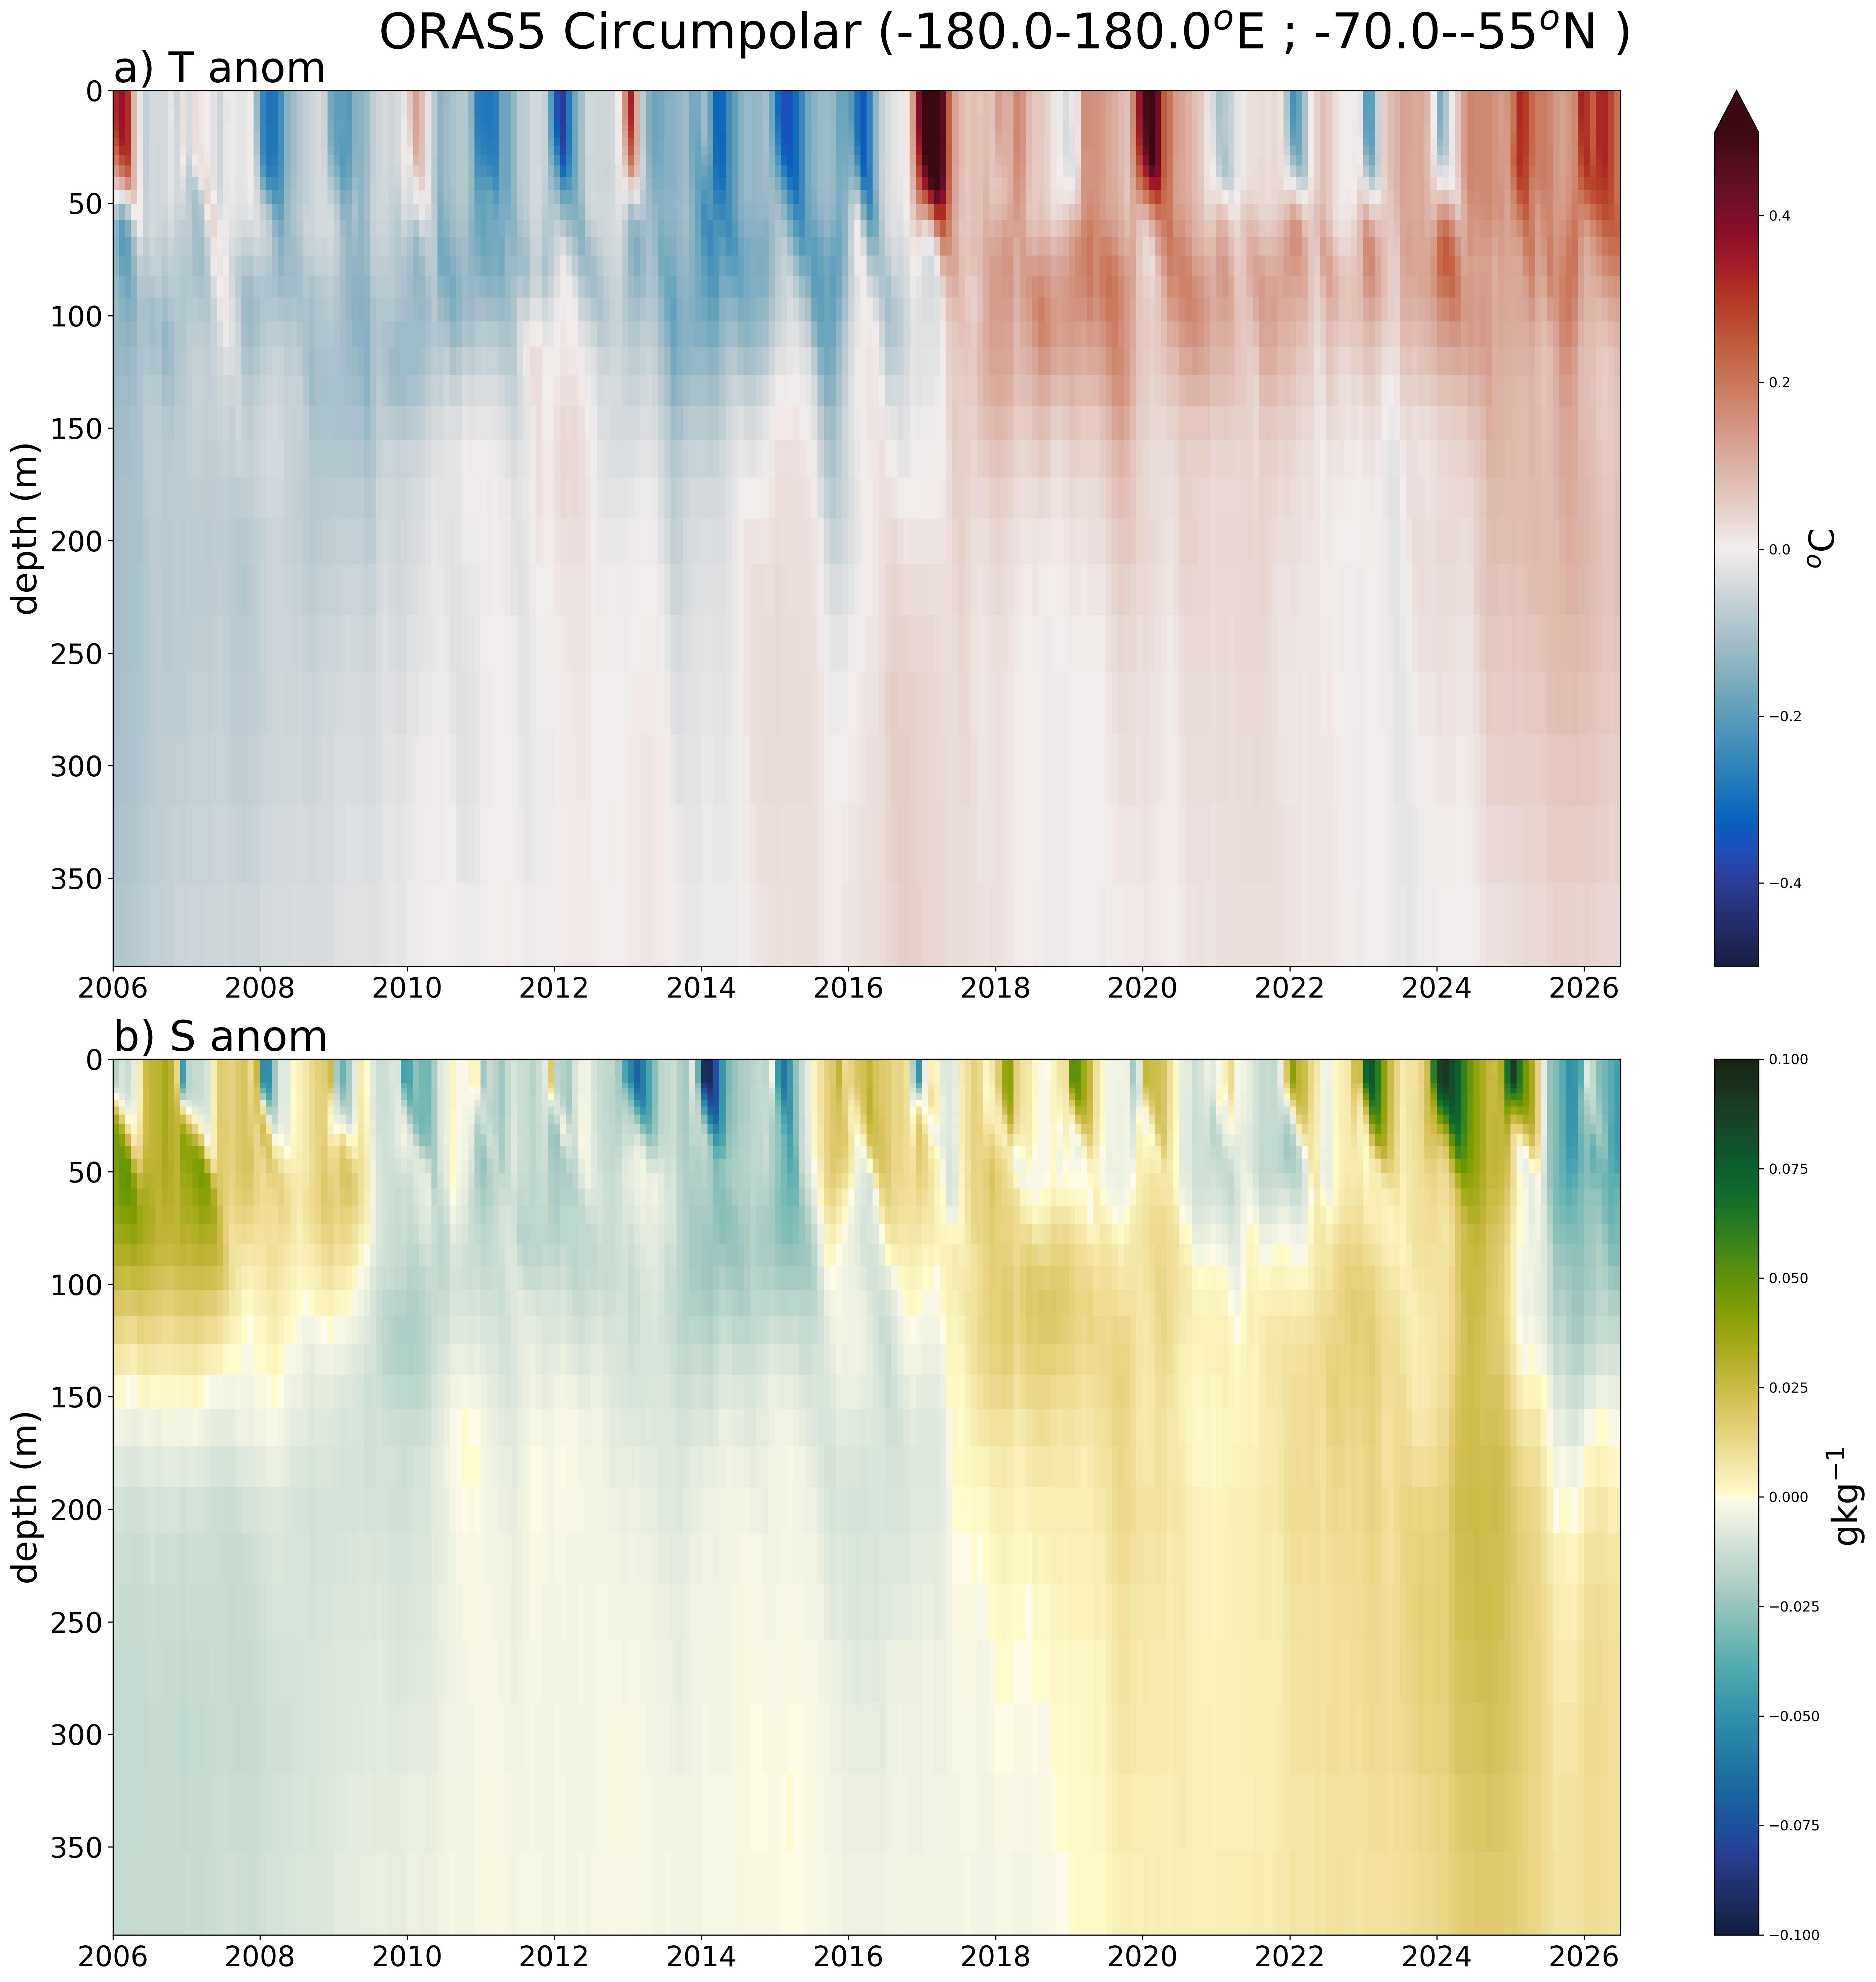

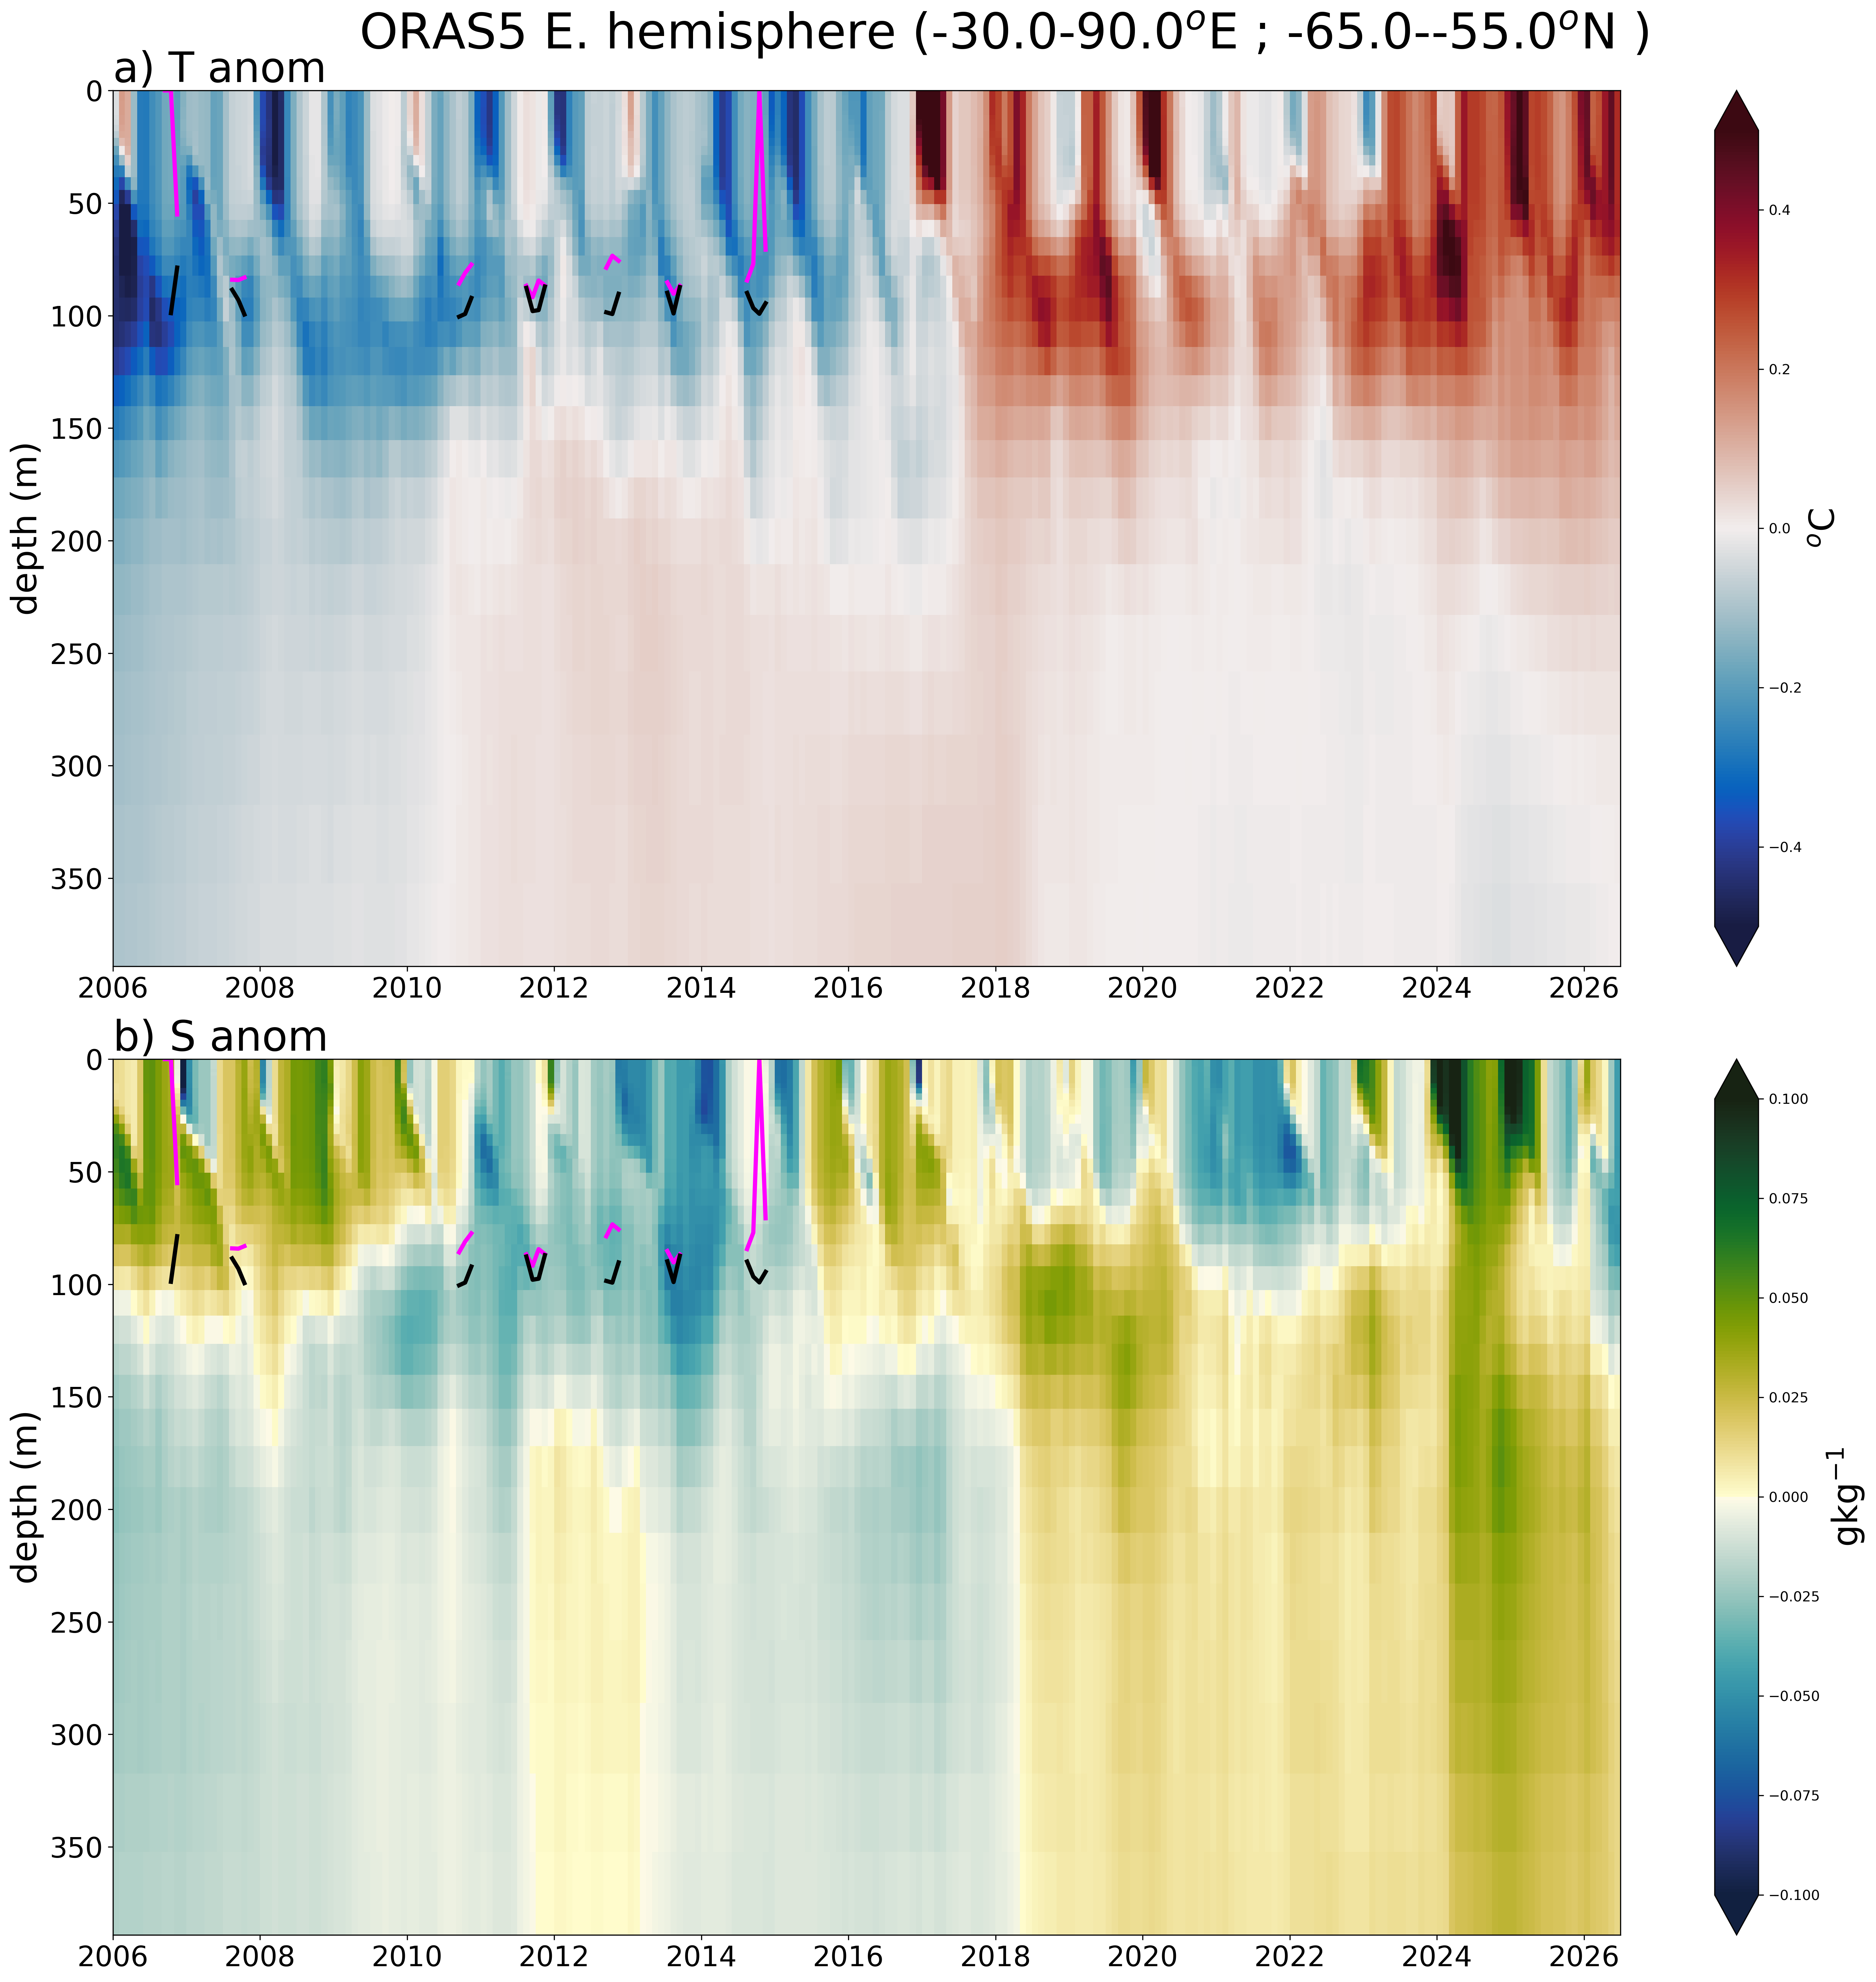

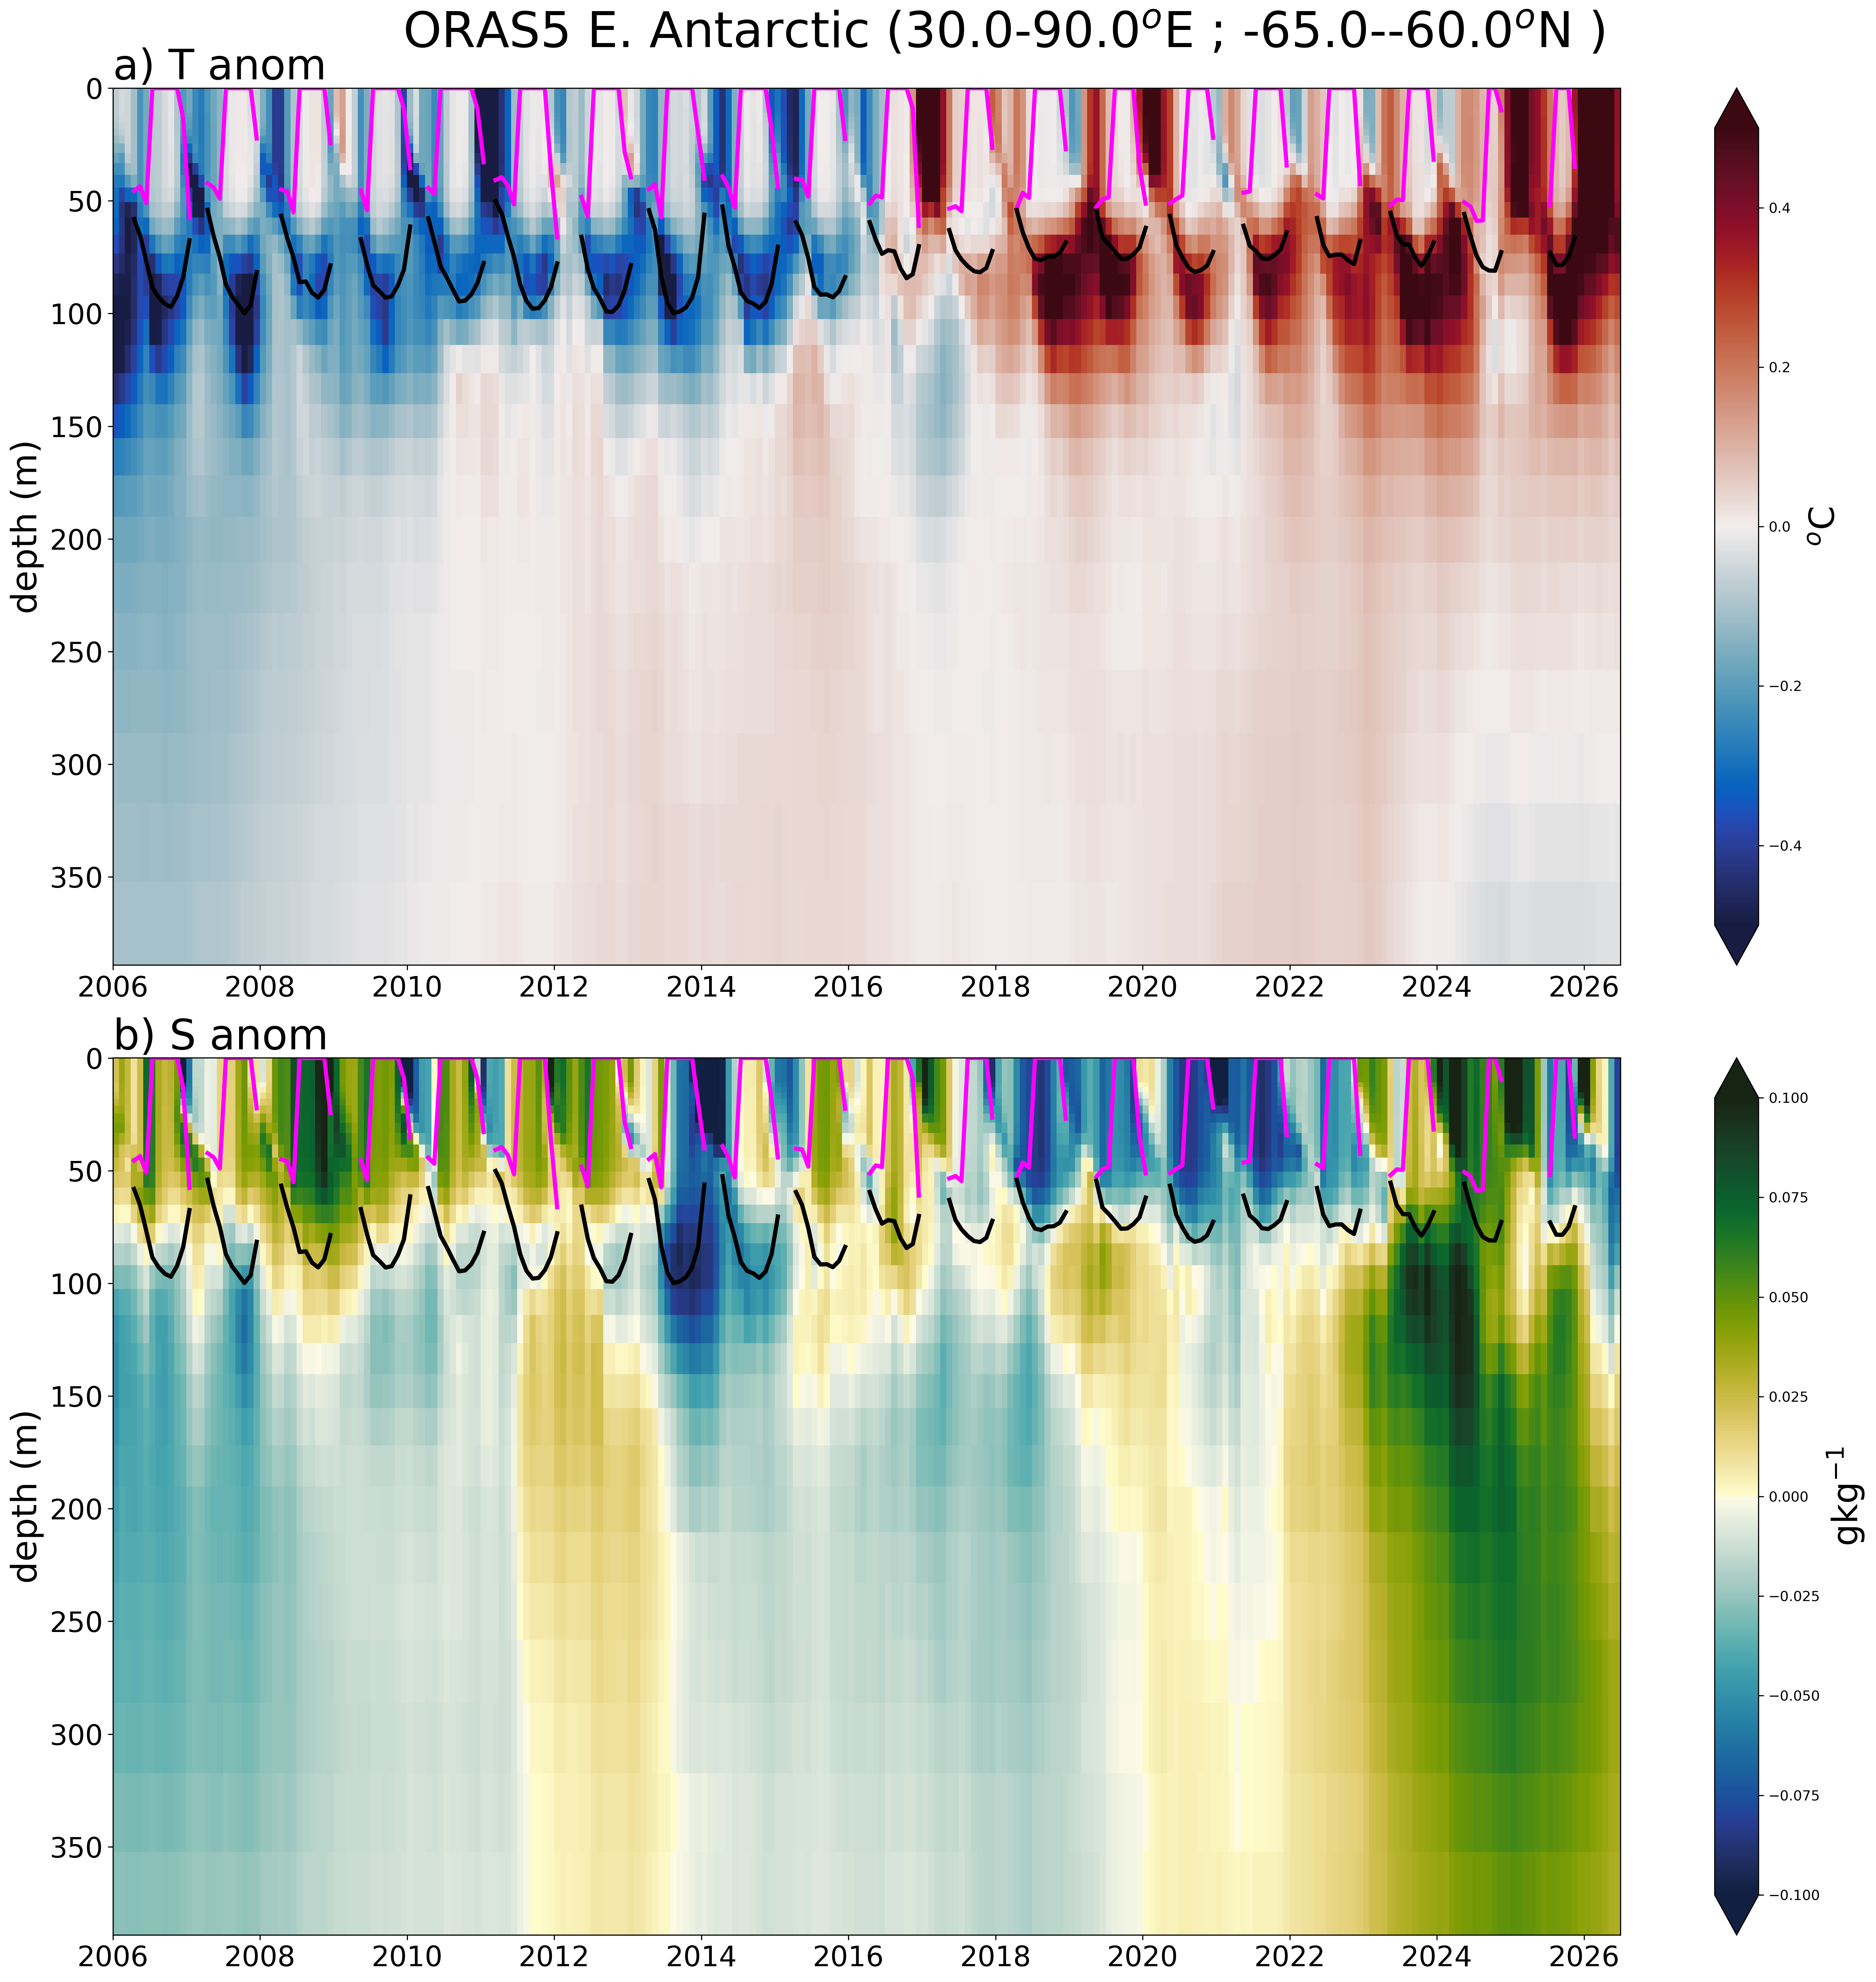

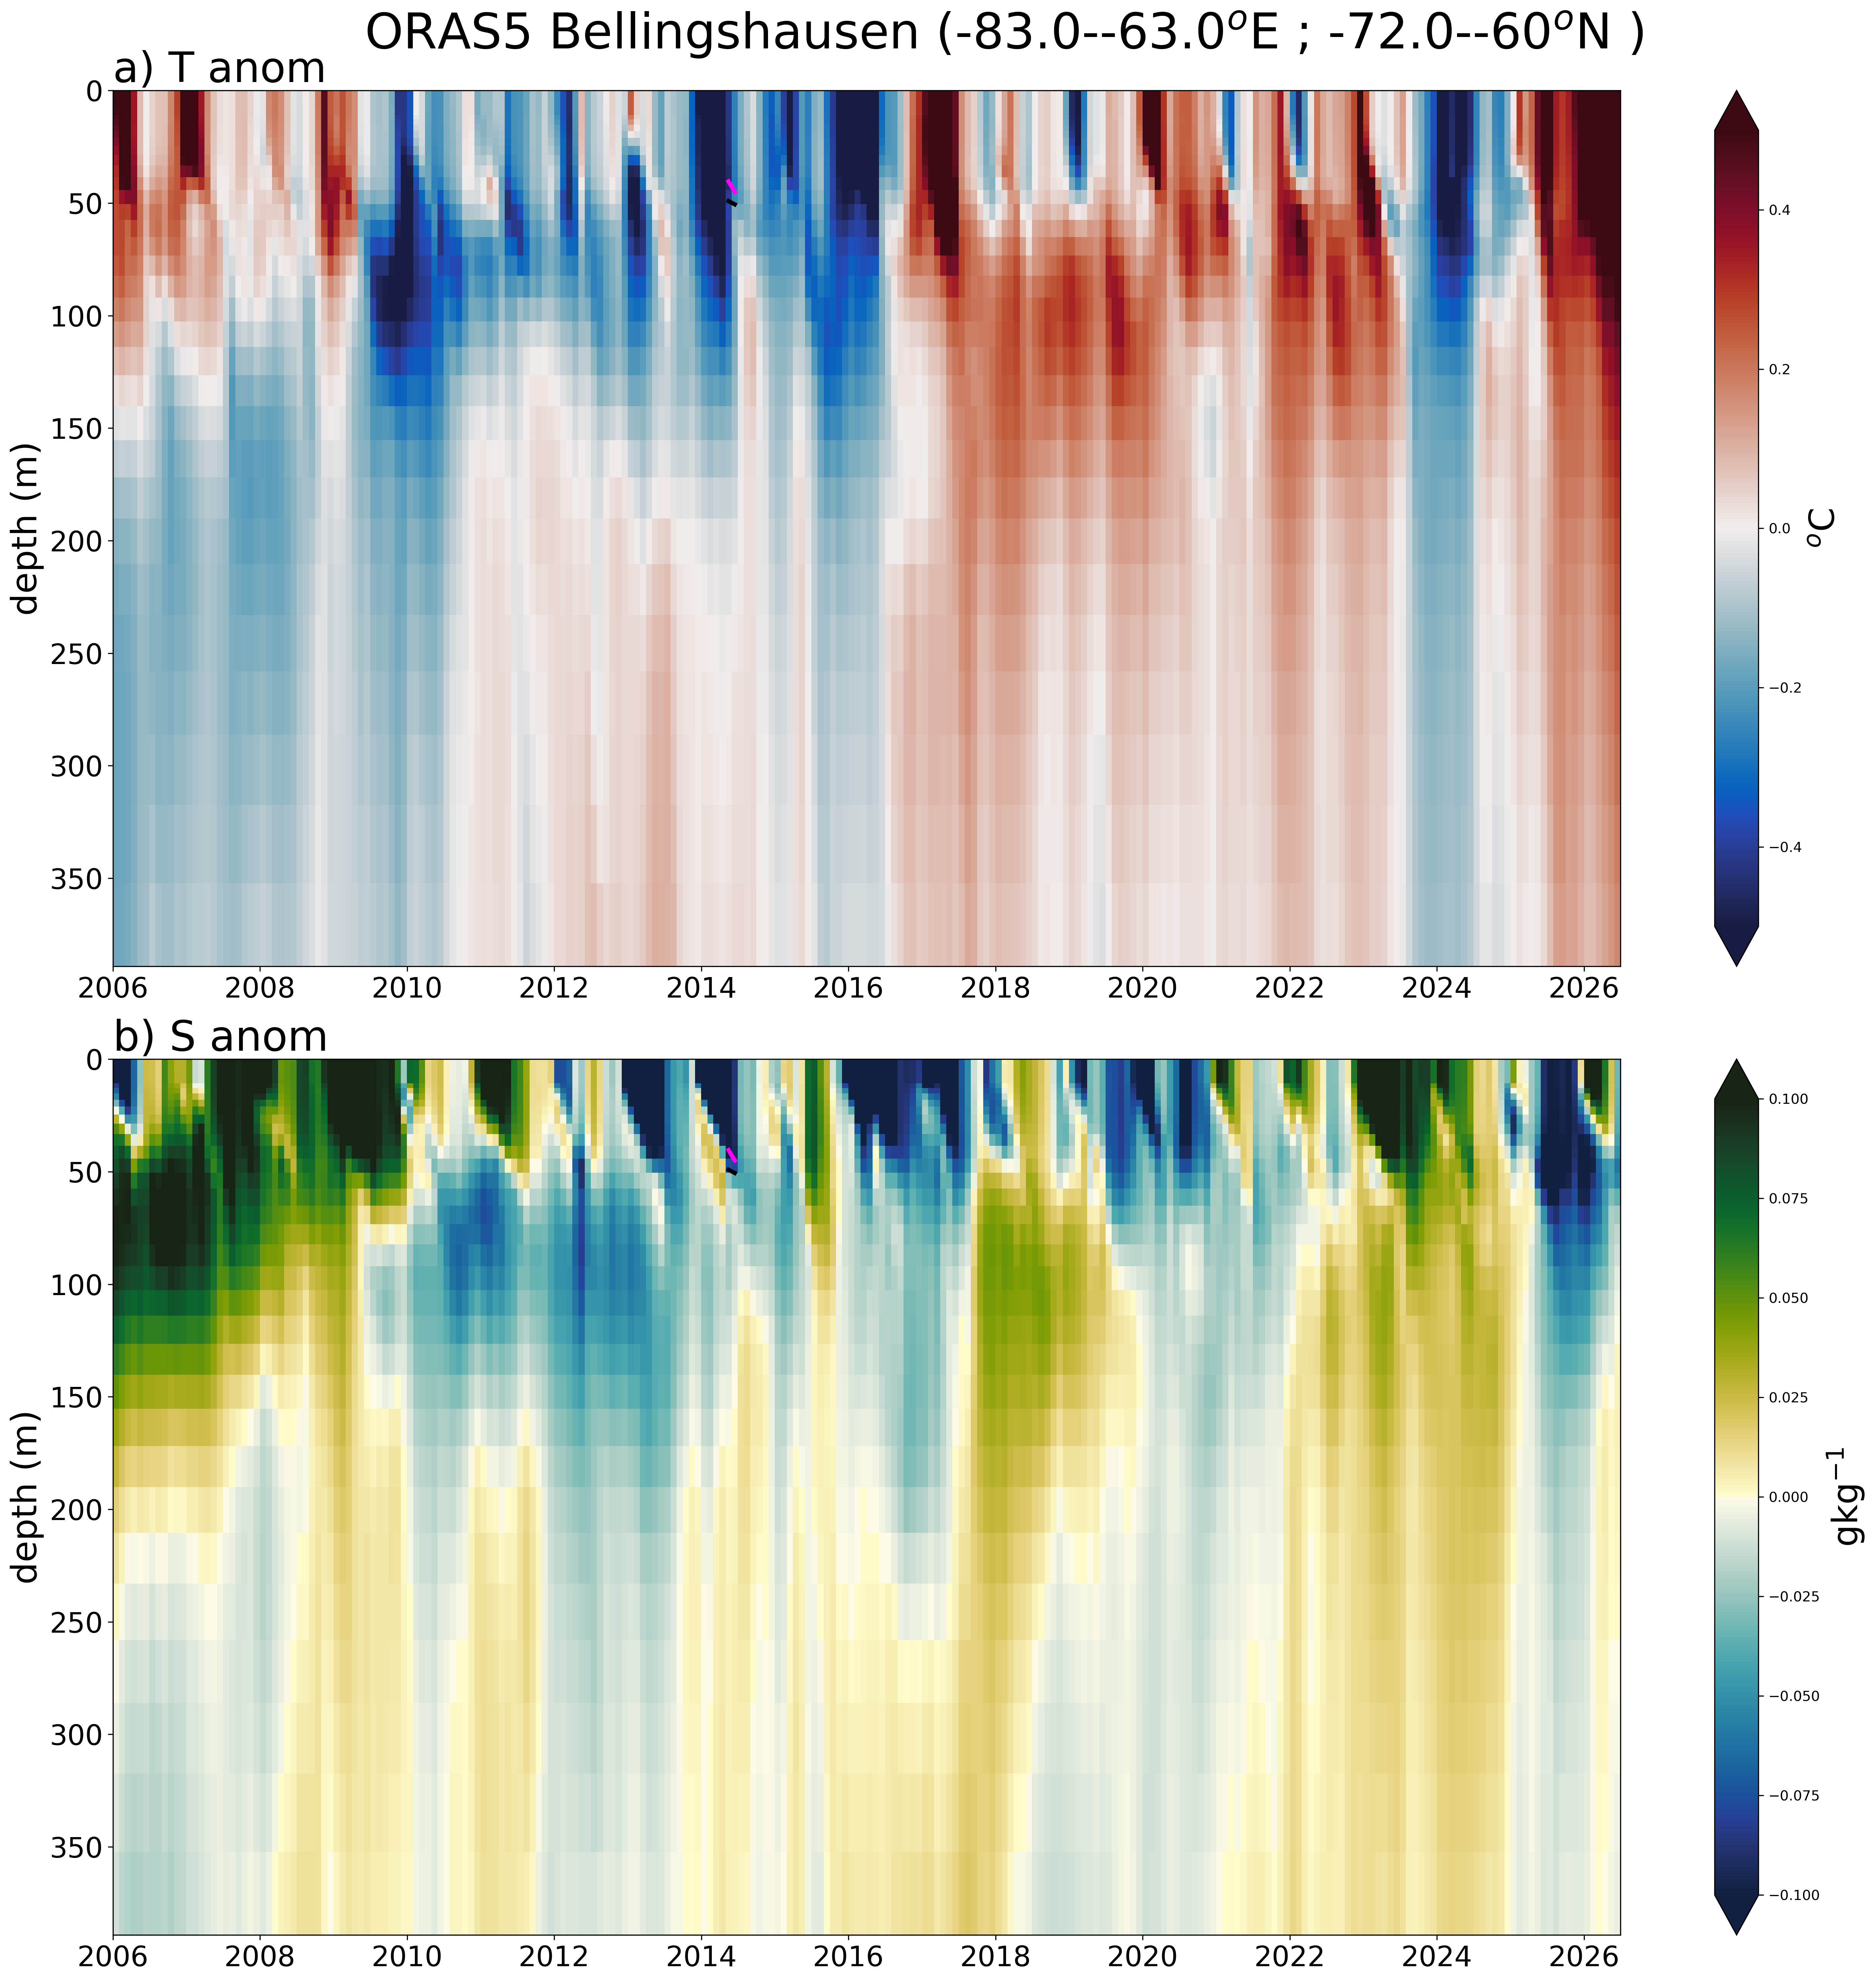

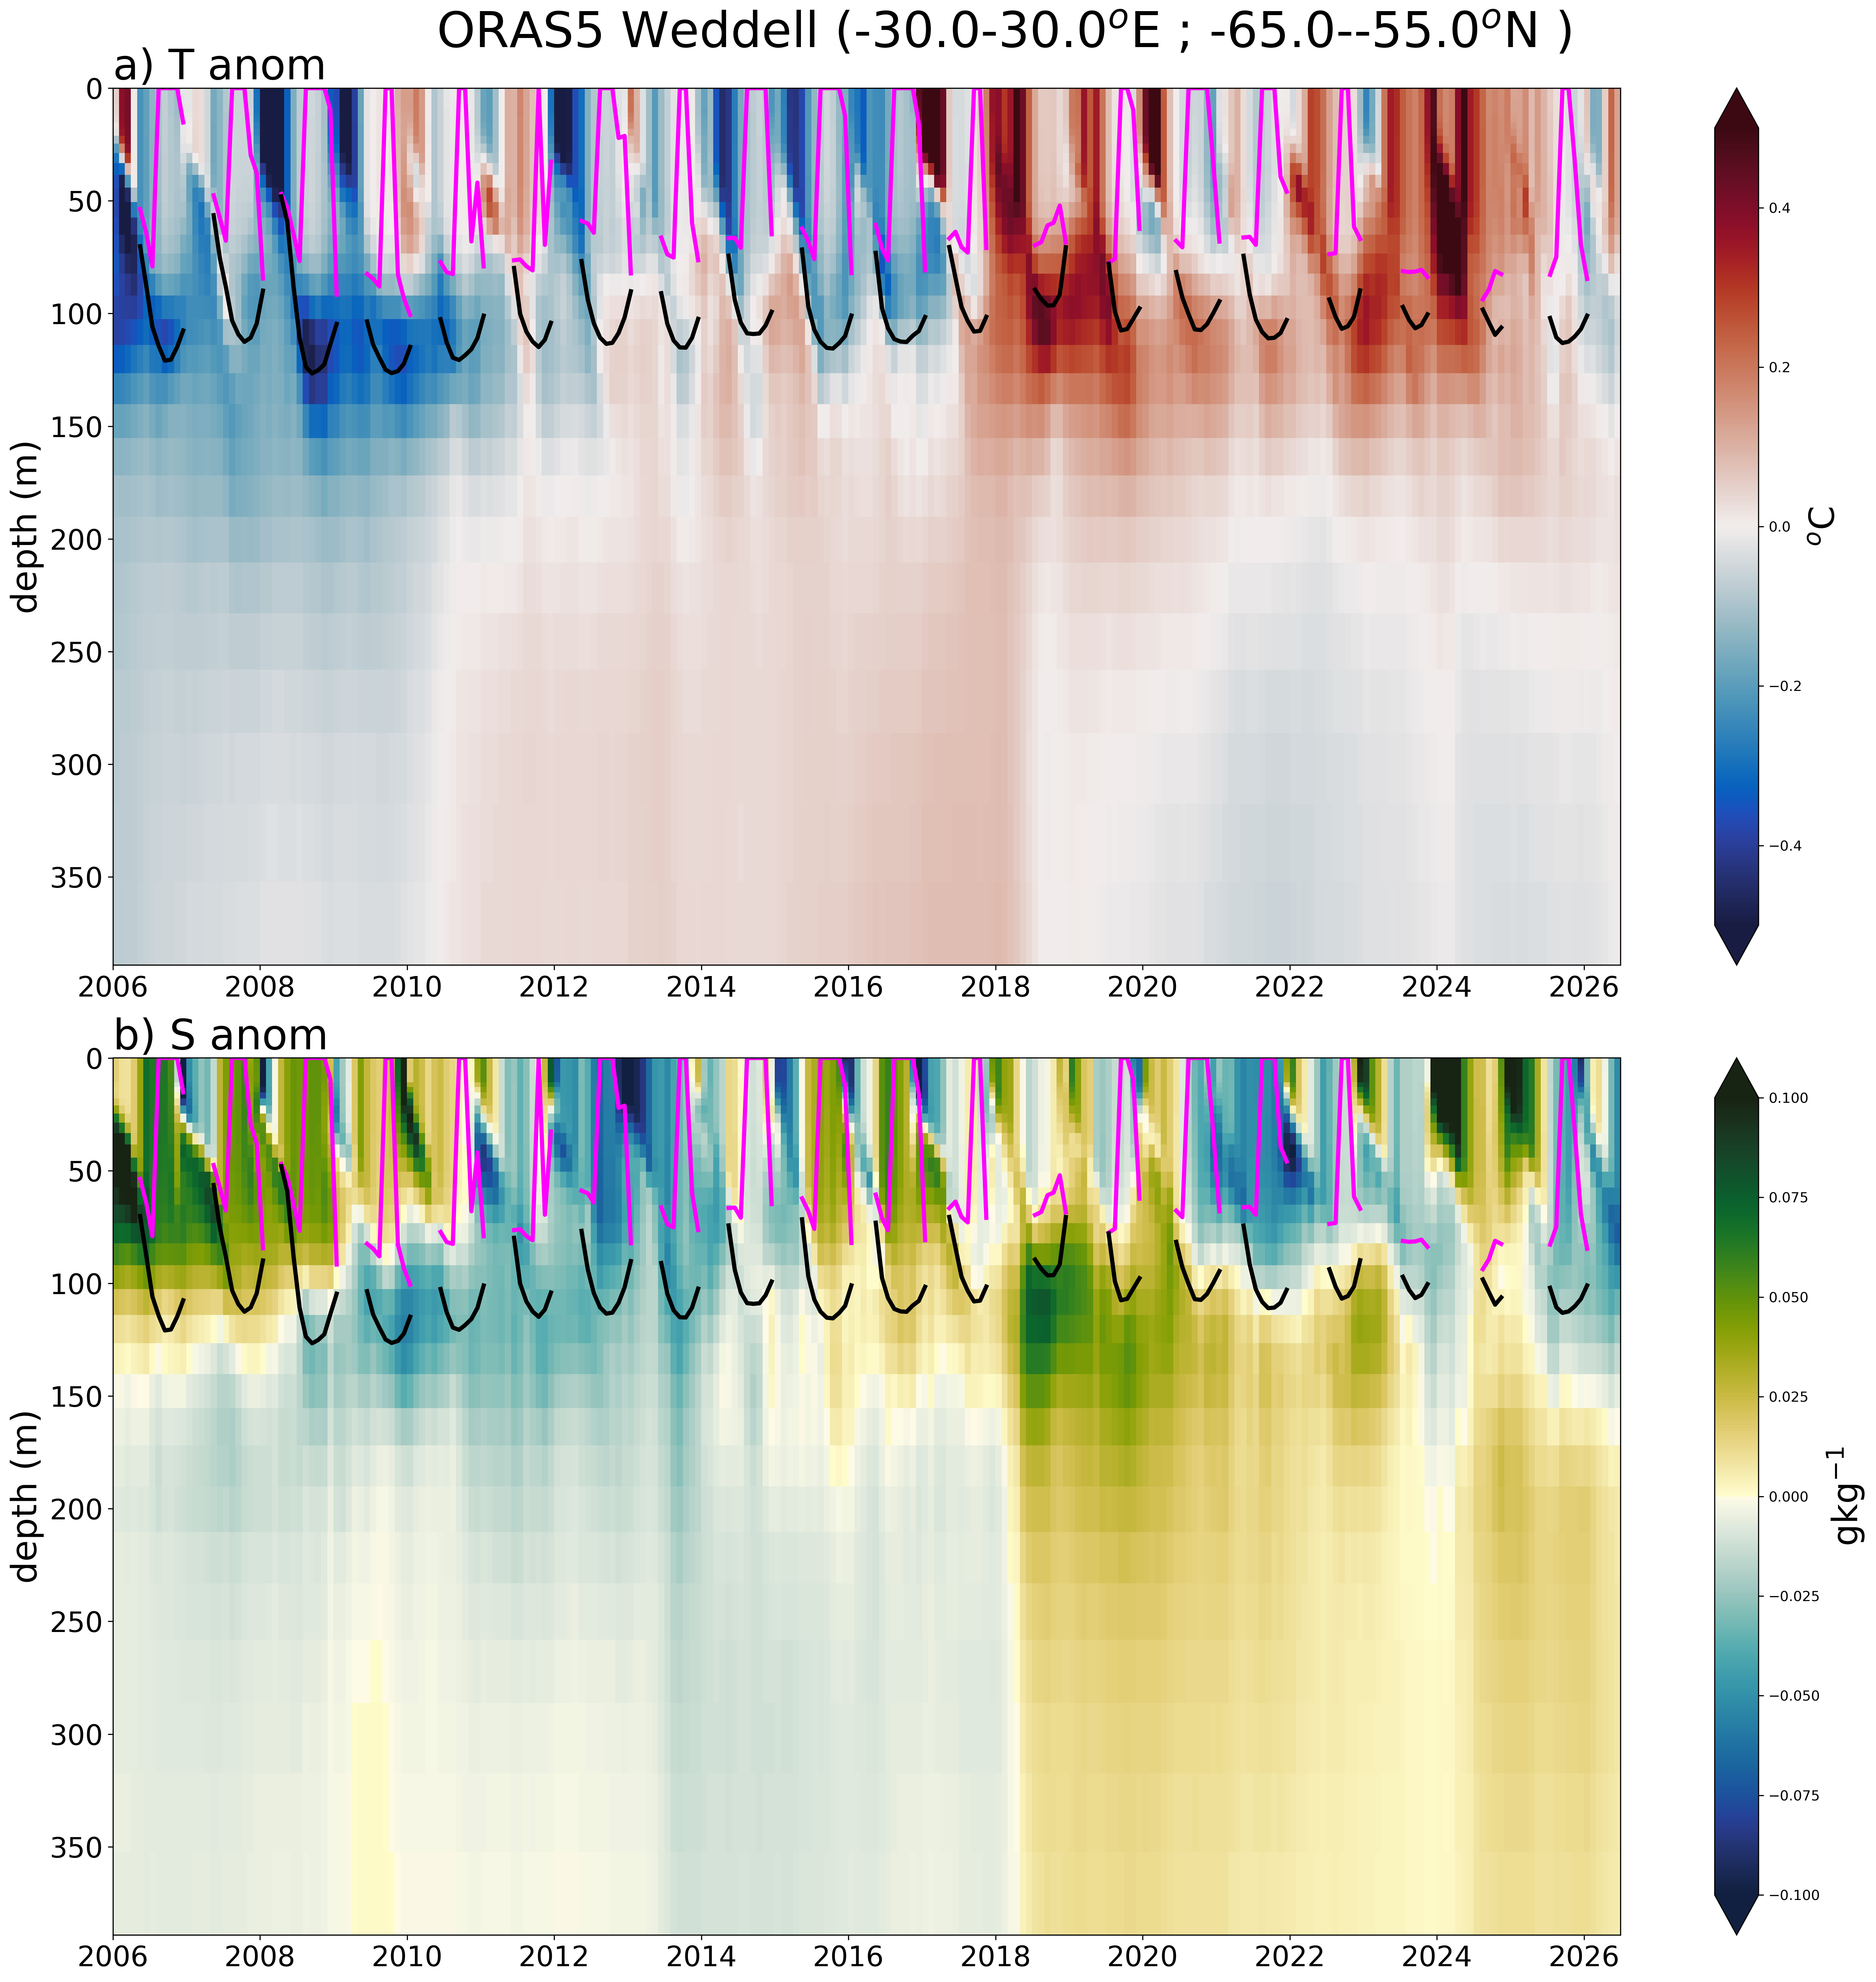

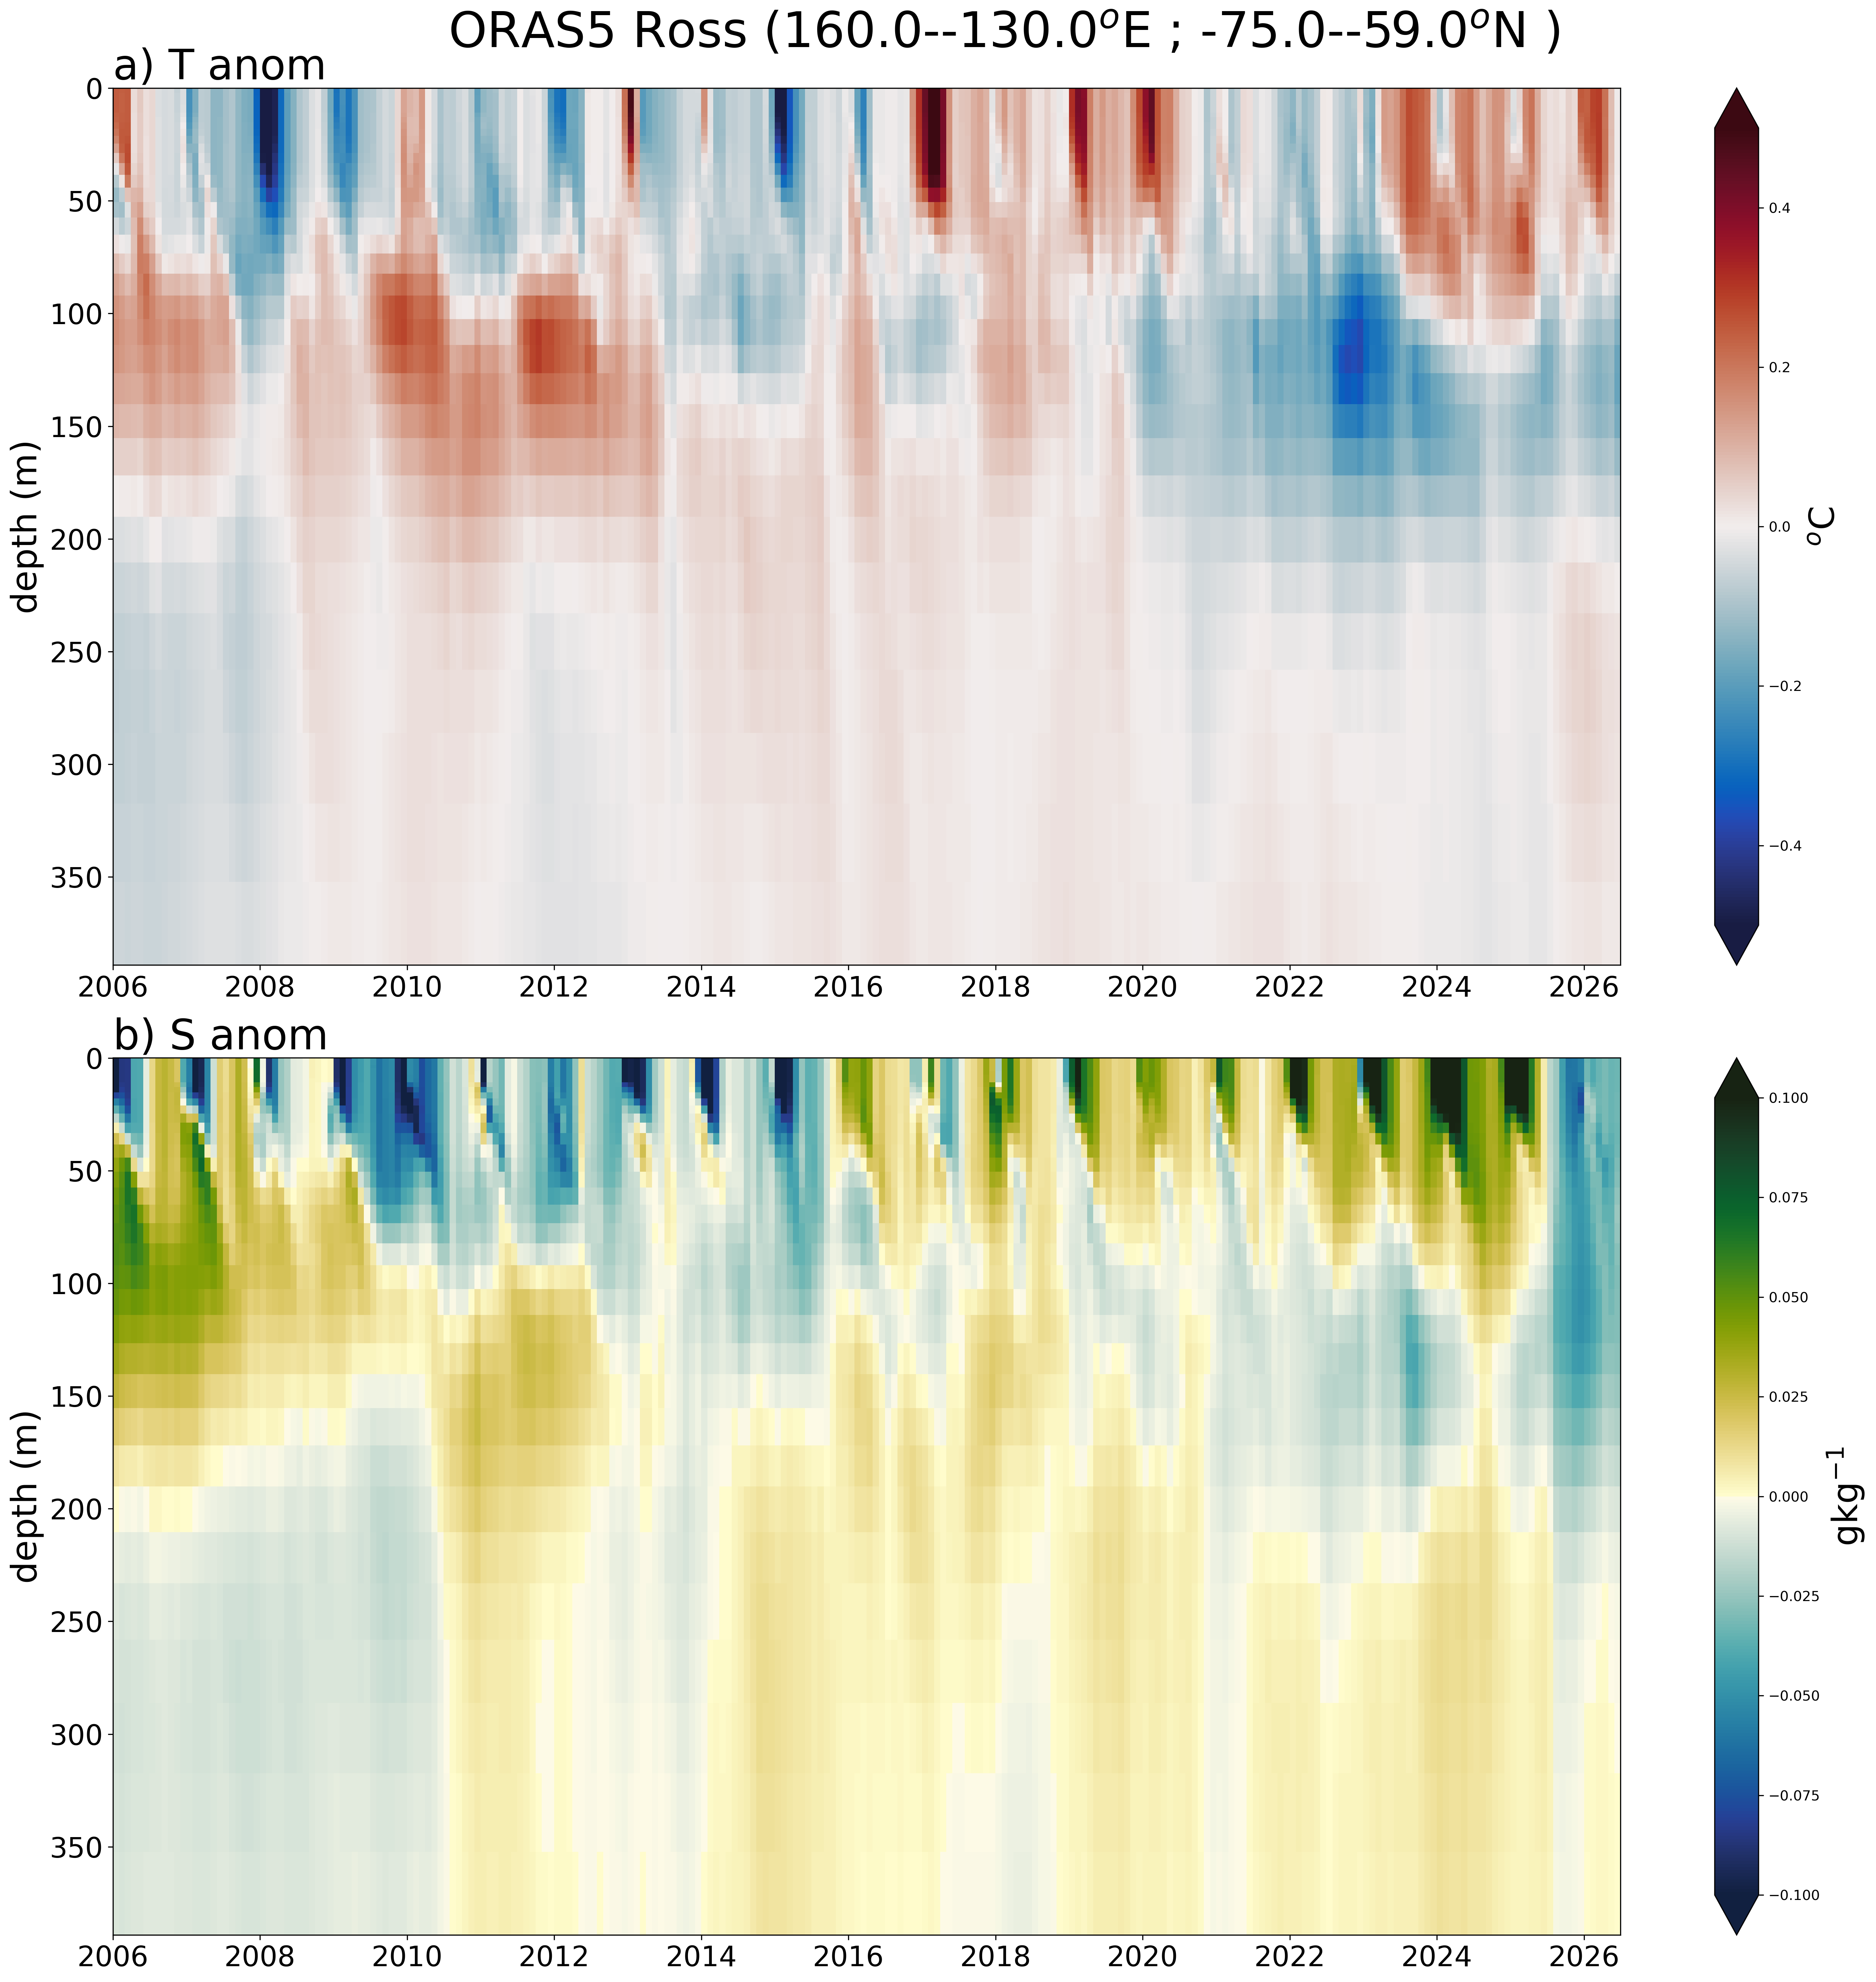

In [14]:
for splot in sector_mean.sector.values:
    sector_anom_plot(splot)
    plt.savefig(diro+src+'_'+splot+'_depth-time_sector_mean_anoms.png')




In [16]:
Client.close()